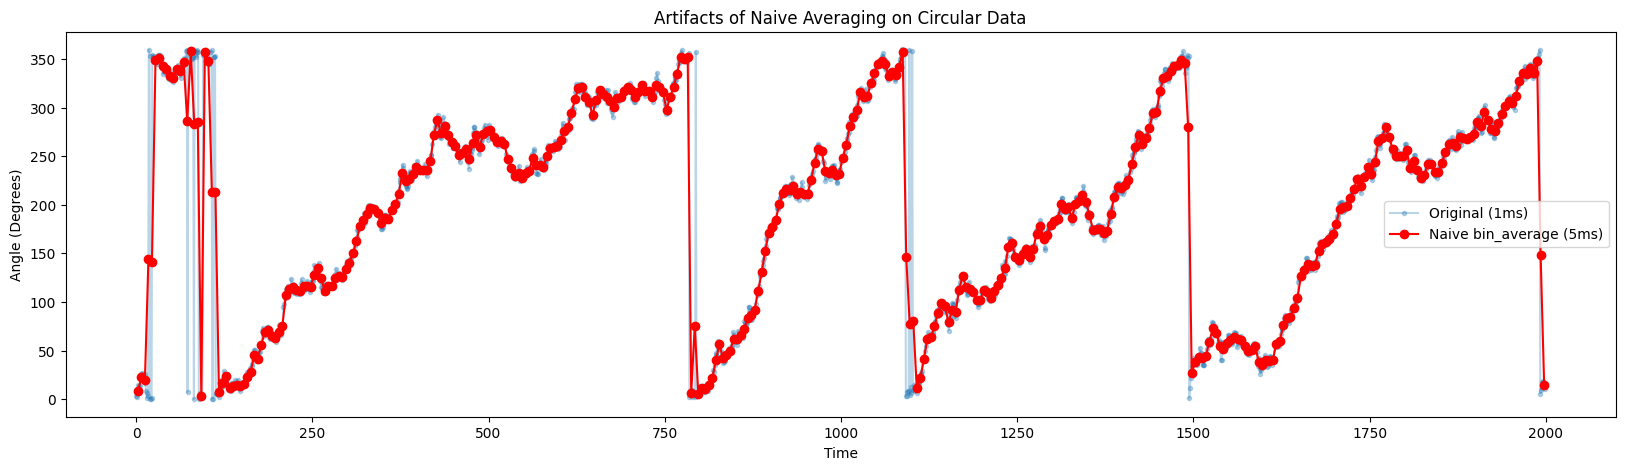

In [10]:
import numpy as np
import pynapple as nap
import matplotlib.pyplot as plt

### Generate circular random walk data
np.random.seed(42)
t = np.arange(2000)
angular_velocity = np.random.normal(loc=0.5, scale=5.0, size=len(t))
# Integrate (cumulative sum) to get continuous position
continuous_random_walk = np.cumsum(angular_velocity)
# Wrap to 0-360 degrees
c = continuous_random_walk % 360

c = nap.Tsd(t=t, d=c)
fig, ax = plt.subplots(figsize=(20, 5))

# 1. Original data
ax.plot(c.times(), c.values, '.-', alpha=0.3, label='Original (1ms)')
# 2. Naive bin average
c_naive = c.bin_average(5)
ax.plot(c_naive.times(), c_naive.values, 'ro-', label='Naive bin_average (5ms)')
# ax.set_xlim(50, 200) # crosses 0/360

ax.set_ylabel('Angle (Degrees)')
ax.set_xlabel('Time')
ax.set_title('Artifacts of Naive Averaging on Circular Data')
ax.legend()
plt.show()

### The Circular Mean
The method implemented below is the standard approach for calculating the mean of circular quantities (also known as the **circular mean**). It is a fundamental concept in the field of **Directional Statistics**.

**Key Resources & Citations:**
1. **Textbooks:**
   - Fisher, N. I. (1993). *Statistical Analysis of Circular Data*. Cambridge University Press. (See Section 2.2.2 on Mean direction).
   - Mardia, K. V., & Jupp, P. E. (2000). *Directional Statistics*. John Wiley & Sons.
2. **Software Implementations:**
   - This exact mathematical approach is used in standard scientific libraries, such as SciPy's [`scipy.stats.circmean`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.circmean.html).
3. **Online Resources:**
   - Wikipedia: [Mean of circular quantities](https://en.wikipedia.org/wiki/Mean_of_circular_quantities)

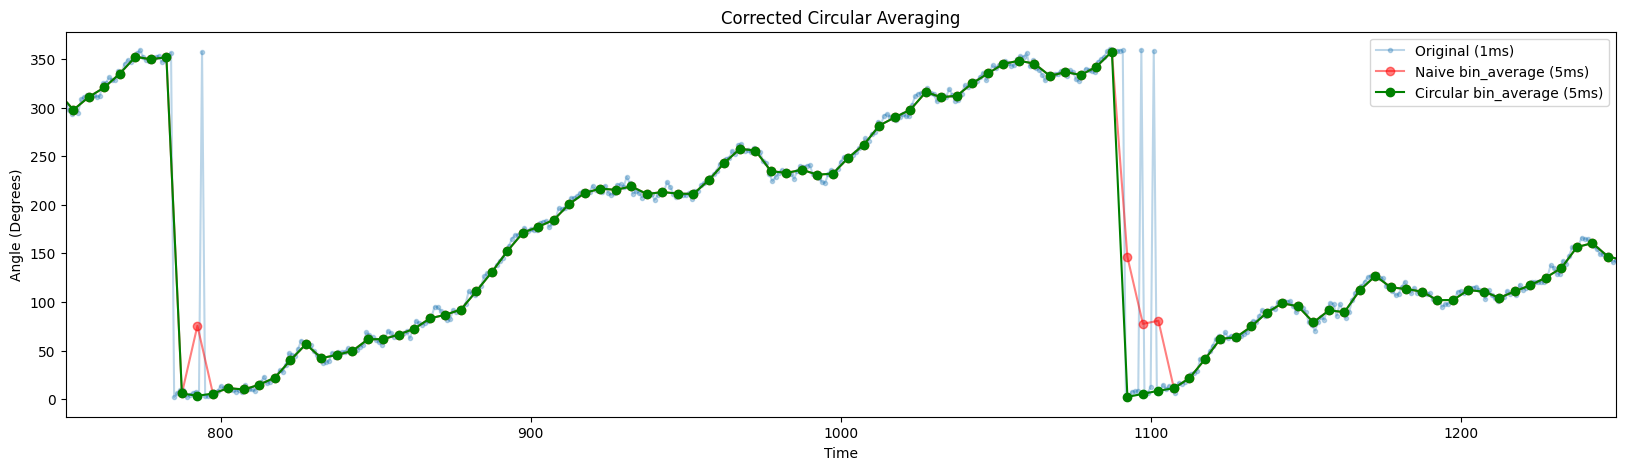

In [14]:
def circular_bin_average(tsd, bin_size, is_degrees=True):
    """
    Computes the binned average of circular data using Cartesian coordinates.
    """
    # 1. Convert to radians if necessary
    angles = np.deg2rad(tsd.values) if is_degrees else tsd.values
    
    # 2. Convert to Cartesian coordinates
    x = np.cos(angles)
    y = np.sin(angles)
    
    # Create temporary Tsd objects for x and y
    x_tsd = nap.Tsd(t=tsd.times(), d=x, time_support=tsd.time_support)
    y_tsd = nap.Tsd(t=tsd.times(), d=y, time_support=tsd.time_support)
    
    # 3. Bin average the Cartesian components
    x_binned = x_tsd.bin_average(bin_size)
    y_binned = y_tsd.bin_average(bin_size)
    
    # 4. Compute mean angle using arctan2
    mean_angles = np.arctan2(y_binned.values, x_binned.values)
    
    # 5. Convert back to degrees and wrap to [0, 360)
    if is_degrees:
        mean_angles = np.rad2deg(mean_angles) % 360
    else:
        mean_angles = mean_angles % (2 * np.pi)
        
    return nap.Tsd(t=x_binned.times(), d=mean_angles, time_support=x_binned.time_support)

# Apply the circular bin average
c_circ_binned = circular_bin_average(c, 5)

# Plot to compare
fig, ax = plt.subplots(figsize=(20, 5))

ax.plot(c.times(), c.values, '.-', alpha=0.3, label='Original (1ms)')
ax.plot(c_naive.times(), c_naive.values, 'ro-', alpha=0.5, label='Naive bin_average (5ms)')
ax.plot(c_circ_binned.times(), c_circ_binned.values, 'go-', label='Circular bin_average (5ms)')

ax.set_xlim(750, 1250) # boundary crossing
ax.set_ylabel('Angle (Degrees)')
ax.set_xlabel('Time')
ax.set_title('Corrected Circular Averaging')
ax.legend()
plt.show()